In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

In [3]:
np.random.seed(42)
delhi_lat=np.random.normal(28.6139,0.003,100)
delhi_lon=np.random.normal(77.2090,0.003,100)

noida_lat=np.random.normal(28.5355,0.003,100)
noida_lon=np.random.normal(77.3910,0.003,100)

gurgaon_lat=np.random.normal(28.4595,0.003,100)
gurgaon_lon=np.random.normal(77.0266,0.003,100)

outlier_lat=[29.10,29.30,28.00]
outlier_lon=[78.20,76.50,79.00]

In [4]:
latitude=np.concatenate([
    delhi_lat,
    noida_lat,
    gurgaon_lat,
    outlier_lat
])
longitude=np.concatenate([
    delhi_lon,
    noida_lon,
    gurgaon_lon,
    outlier_lon
])
df=pd.DataFrame({
    "latitude":latitude,
    "longitude":longitude
})
df.head()

,latitude,longitude
0,28.615390,77.204754
1,28.613485,77.207738
2,28.615843,77.207972
3,28.618469,77.206593
4,28.613198,77.208516


In [5]:
df.to_csv("gps_location.csv",index=False)

In [6]:
df.shape

(303, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   303 non-null    float64
 1   longitude  303 non-null    float64
dtypes: float64(2)
memory usage: 4.9 KB


In [9]:
df.isnull().sum()

latitude     0
longitude    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

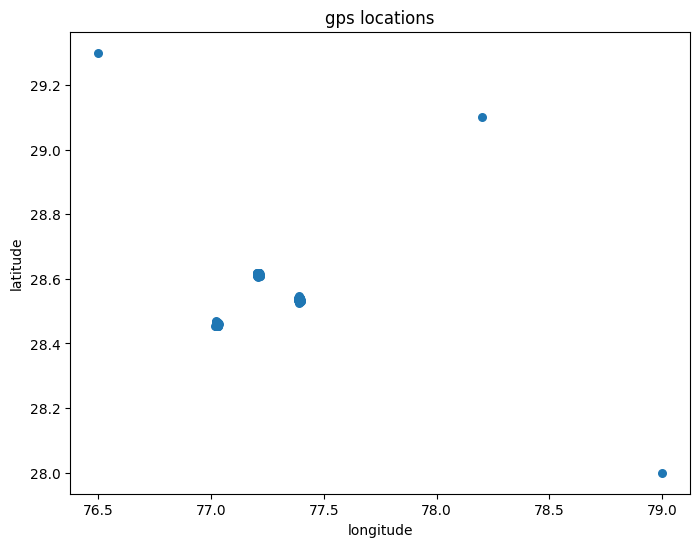

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(
    df['longitude'],
    df['latitude'],
    s=30
)
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.title('gps locations')
plt.show()

In [12]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)

In [13]:
dbscan=DBSCAN(eps=0.3,min_samples=5)
clusters=dbscan.fit_predict(X_scaled)

In [14]:
df['Cluster']=clusters

In [15]:
df.head()

,latitude,longitude,Cluster
0,28.615390,77.204754,0
1,28.613485,77.207738,0
2,28.615843,77.207972,0
3,28.618469,77.206593,0
4,28.613198,77.208516,0


In [16]:
df['Cluster'].value_counts()

Cluster
 0    100
 1    100
 2    100
-1      3
Name: count, dtype: int64

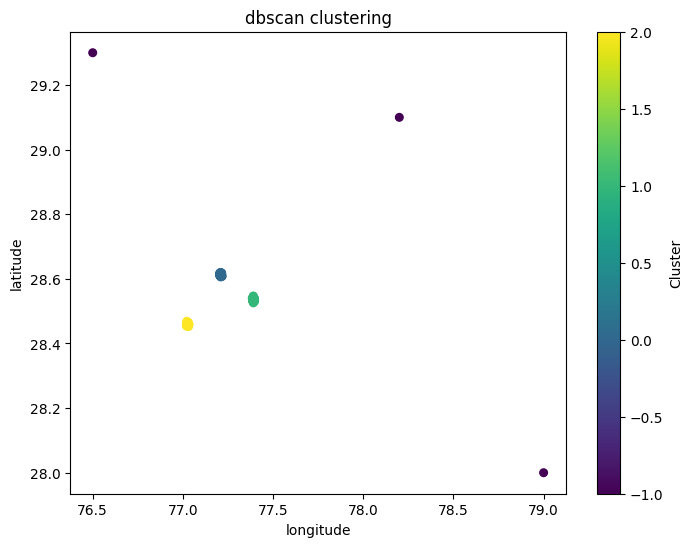

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['Cluster'],
    cmap='viridis',
    s=30
)
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.title('dbscan clustering')
plt.colorbar(label='Cluster')
plt.show()

In [20]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans.fit(X_scaled)
kmeans_clusters=kmeans.predict(X_scaled)
df['KMeans_Cluster']=kmeans_clusters

In [21]:
df.head()

,latitude,longitude,Cluster,KMeans_Cluster
0,28.615390,77.204754,0,2
1,28.613485,77.207738,0,2
2,28.615843,77.207972,0,2
3,28.618469,77.206593,0,2
4,28.613198,77.208516,0,2


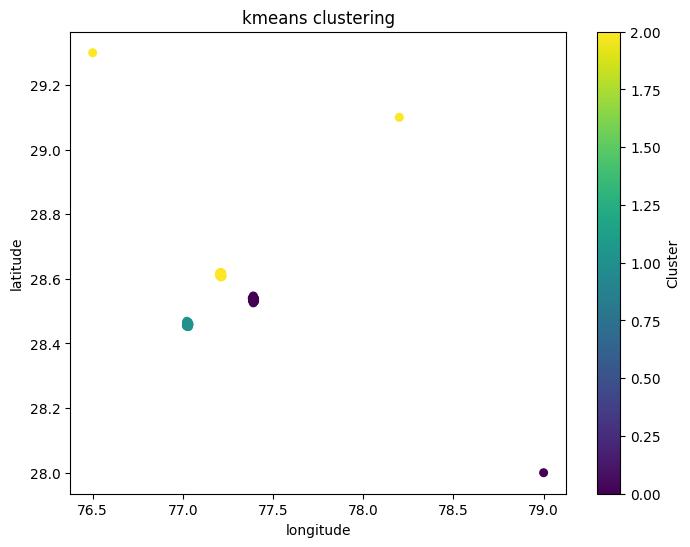

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(df['longitude'],
            df['latitude'],
            c=df['KMeans_Cluster'],
            cmap='viridis',
            s=30
           )
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.title('kmeans clustering')
plt.colorbar(label='Cluster')
plt.show()

In [23]:
df['Cluster'].value_counts()

Cluster
 0    100
 1    100
 2    100
-1      3
Name: count, dtype: int64